In [72]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd 
import corner 
import sklearn.model_selection
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.metrics import recall_score, roc_curve, precision_score
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from astroML.classification import GMMBayes
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_auc_score
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV
from astroML.utils import completeness_contamination



SDSS Galaxies and Quasar

In [73]:
# import the CSV file with the data
data = pd.read_csv("galaxyquasar.csv")
# print the first few rows of the data to check it loaded correctly
print(data.head())  
print(data.columns)



          u         g         r         i         z   class        z1  \
0  18.97213  18.53676  18.58280  18.34936  18.29215     QSO  0.522819   
1  19.24592  17.47646  16.47817  16.04472  15.68851  GALAXY  0.122846   
2  19.43536  17.70268  16.91565  16.58327  16.39128  GALAXY  0.000000   
3  19.31626  18.18312  17.39591  16.94549  16.65395  GALAXY  0.147435   
4  19.28828  19.11188  18.88937  18.80013  18.49183     QSO  2.011455   

       zerr  
0  0.000155  
1  0.000028  
2  0.000000  
3  0.000009  
4  0.000631  
Index(['u', 'g', 'r', 'i', 'z', 'class', 'z1', 'zerr'], dtype='str')


In [74]:
#identify the columns we need as labels and the features
labels = "class"
features = [col for col in data.columns if col != labels]
print("Features:", features)
print("Target:", labels)

Features: ['u', 'g', 'r', 'i', 'z', 'z1', 'zerr']
Target: class


In [75]:
# Create an array for the u-g color index
data["u-g"] = data["u"] - data["g"]
# Create an array for the g-r color index
data["g-r"] = data["g"] - data["r"]
# Create an array for the r-i color index
data["r-i"] = data["r"] - data["i"]
# Create an array for the i-z color index
data["i-z"] = data["i"] - data["z"]

# Create an array with the galaxies and the quasars marked as 0 and 1 respectively
data["class_binary"] = data["class"].apply(lambda x: 0 if x == "GALAXY" else 1)

print (data[["u-g", "g-r", "r-i", "i-z", "class_binary"]].head())


       u-g      g-r      r-i      i-z  class_binary
0  0.43537 -0.04604  0.23344  0.05721             1
1  1.76946  0.99829  0.43345  0.35621             0
2  1.73268  0.78703  0.33238  0.19199             0
3  1.13314  0.78721  0.45042  0.29154             0
4  0.17640  0.22251  0.08924  0.30830             1


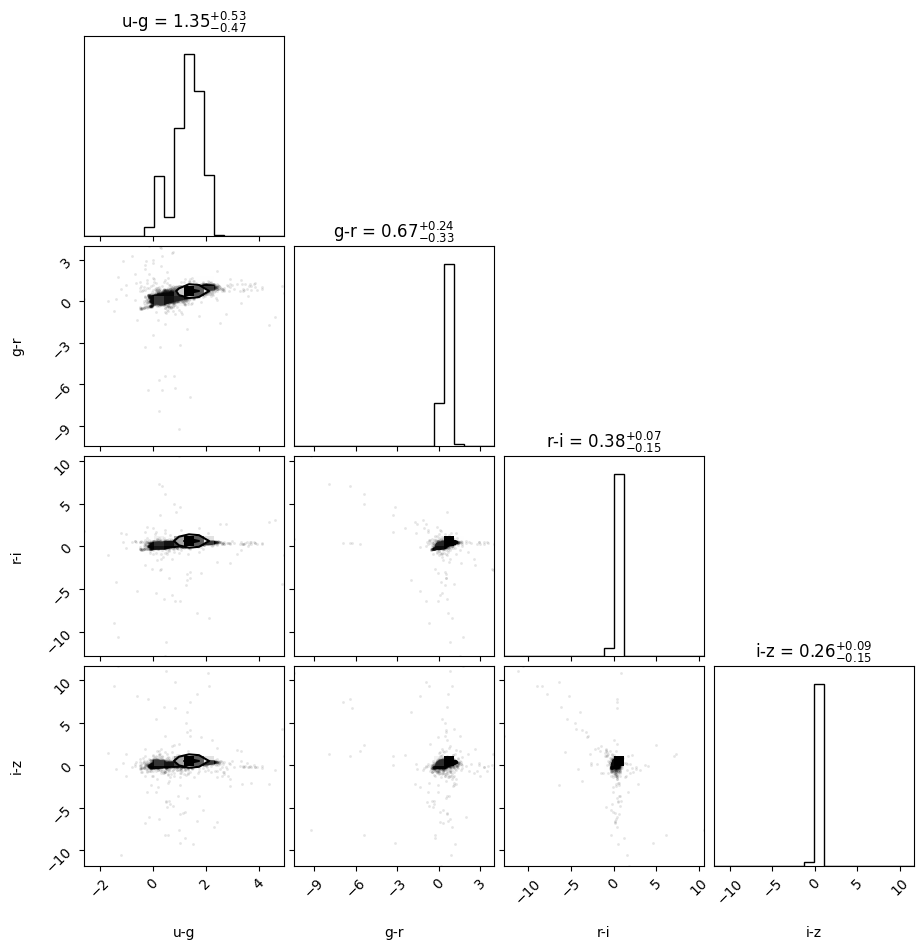

In [76]:
# Perform a corner plot to visualize the distribution of the data in the color-color space
corner.corner(data[["u-g", "g-r", "r-i", "i-z"]], labels=["u-g", "g-r", "r-i", "i-z"], show_titles=True, title_kwargs={"fontsize": 12})
plt.show()



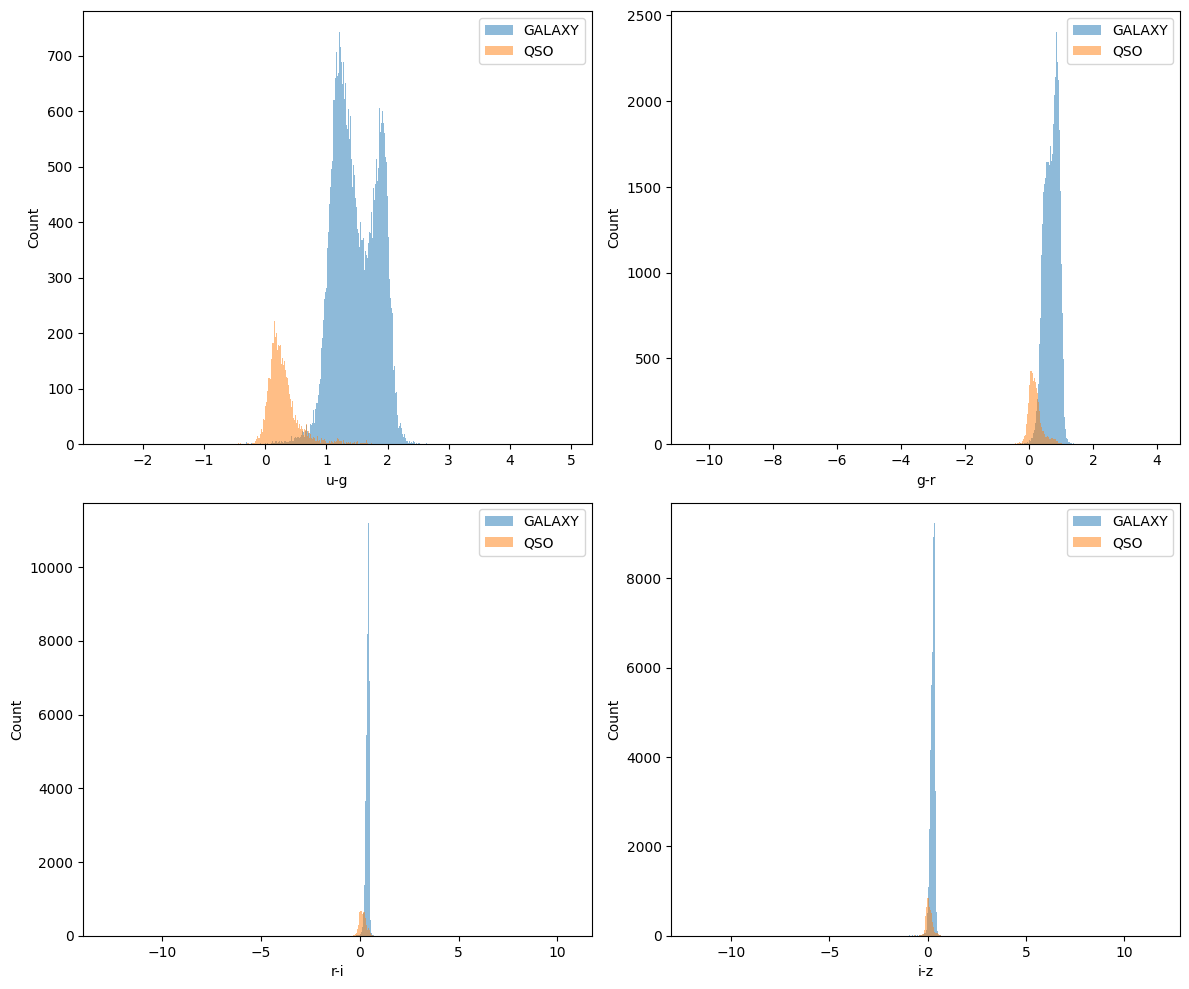

In [77]:
# Plot the 4 color histograms for galaxies and quasars separately

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
color_indices = ["u-g", "g-r", "r-i", "i-z"]

for i, color in enumerate(color_indices):
    ax = axes[i//2, i%2] 
    for label, group in data.groupby("class"):
        ax.hist(group[color], bins=500, alpha=0.5, label=label)

    
    ax.set_xlabel(color)
    ax.set_ylabel("Count")
    ax.legend()

plt.tight_layout()
plt.show()

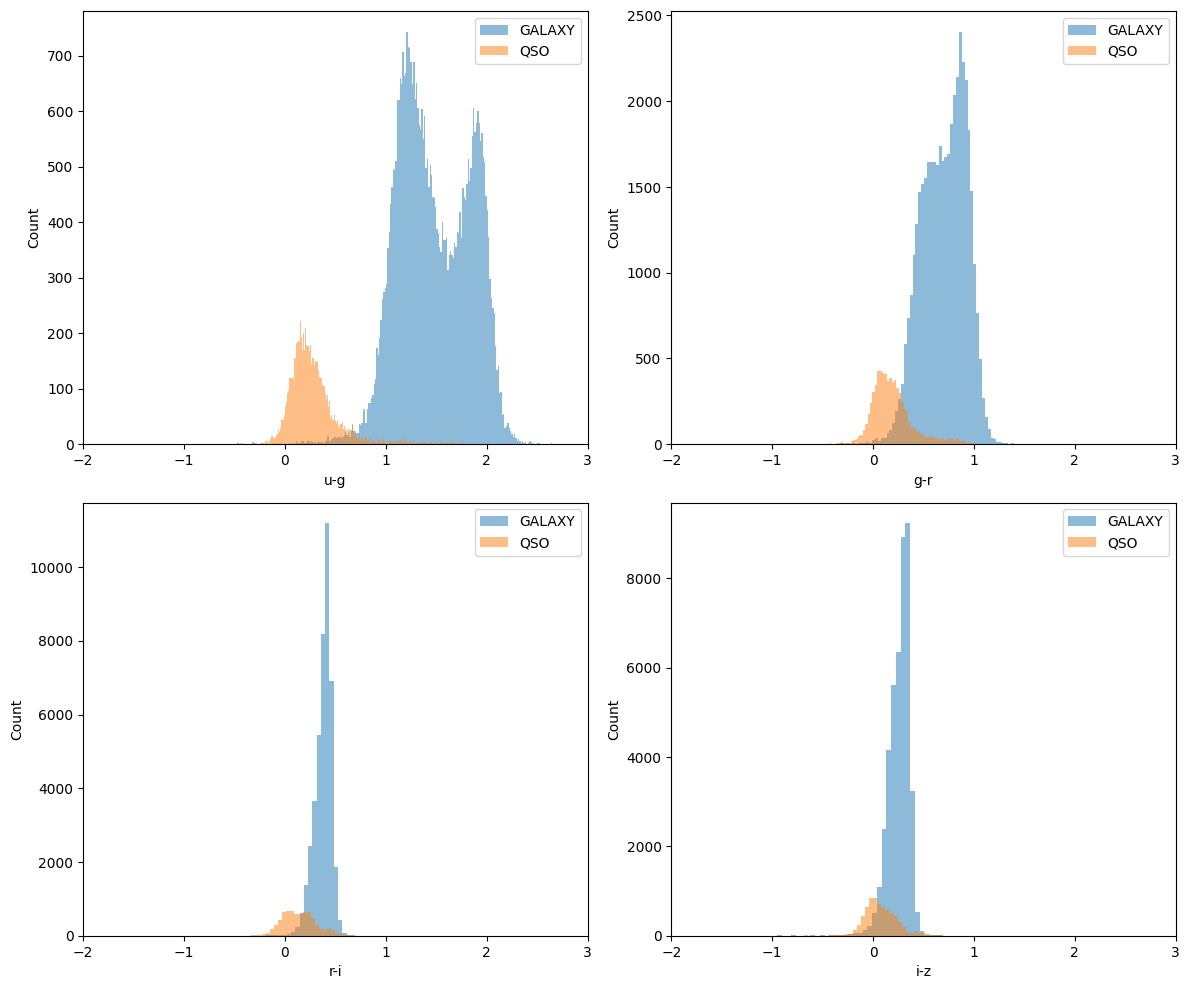

In [78]:
# Now we set a limit in the x axis 

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
color_indices = ["u-g", "g-r", "r-i", "i-z"]

for i, color in enumerate(color_indices):
    ax = axes[i//2, i%2] 
    for label, group in data.groupby("class"):
        ax.hist(group[color], bins=500, alpha=0.5, label=label)

    ax.set_xlim(-2,3)
    ax.set_xlabel(color)
    ax.set_ylabel("Count")
    ax.legend()

plt.tight_layout()
plt.show()

In [79]:
# Print the correlation matrix for the color indices
corr_matrix = data[["u-g", "g-r", "r-i", "i-z"]].corr()
print("Correlation matrix for color indices:")
print(corr_matrix)

Correlation matrix for color indices:
          u-g       g-r       r-i       i-z
u-g  1.000000  0.803315  0.469237  0.360335
g-r  0.803315  1.000000  0.347712  0.318454
r-i  0.469237  0.347712  1.000000 -0.158128
i-z  0.360335  0.318454 -0.158128  1.000000


In [80]:
# From the histograms, we can see that the color distributions of galaxies and quasars overlap significantly, especially in the g-r, r-i and i-z colors. 
# The most important feature for separating the two classes is by eye the u-g color, where quasars tend to have much lower values than galaxies.

# train-test split to perform classification
X = data[["u-g", "g-r", "r-i", "i-z"]].values
y = data["class_binary"].values 
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(X, y, test_size=0.3, random_state=42)
print ("Training set size:", X_train.shape[0])
print ("Test set size:", X_test.shape[0])   
print ("Features array shape:", X_train.shape)


Training set size: 35000
Test set size: 15000
Features array shape: (35000, 4)


Single Feature used: u-g, AUC: 0.980
Single Feature used: g-r, AUC: 0.942
Single Feature used: r-i, AUC: 0.899
Single Feature used: i-z, AUC: 0.841


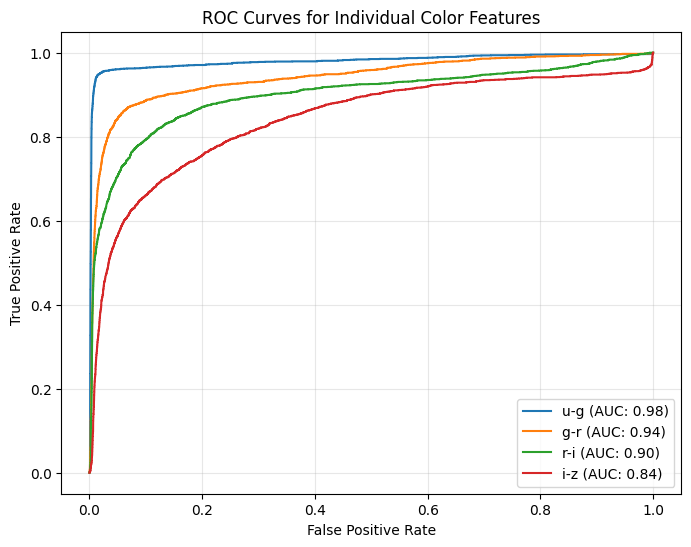

In [81]:
# using the Gaussian Naive Bayes classifier we can see which is the most important feature for separating the two classes
gnb = GaussianNB()

auc_scores_gaus = []

# Roc for individual features
plt.figure(figsize=(8, 6))

for i in range(X_train.shape[1]):

    gnb.fit(X_train[:, i:i+1], y_train)

    y_prob = gnb.predict_proba(X_test[:, i:i+1])[:, 1]
    auc_score = roc_auc_score(y_test, y_prob)
    auc_scores_gaus.append(auc_score)
    
    print(f"Single Feature used: {color_indices[i]}, AUC: {auc_score:.3f}")
    
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{color_indices[i]} (AUC: {auc_score:.2f})")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Individual Color Features")
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

Cumulative Features used: ['u-g']
Completeness (Recall): 0.931, Contamination (1 - Precision): 0.059
Cumulative Features used: ['u-g', 'g-r']
Completeness (Recall): 0.928, Contamination (1 - Precision): 0.095
Cumulative Features used: ['u-g', 'g-r', 'r-i']
Completeness (Recall): 0.927, Contamination (1 - Precision): 0.087
Cumulative Features used: ['u-g', 'g-r', 'r-i', 'i-z']
Completeness (Recall): 0.927, Contamination (1 - Precision): 0.095


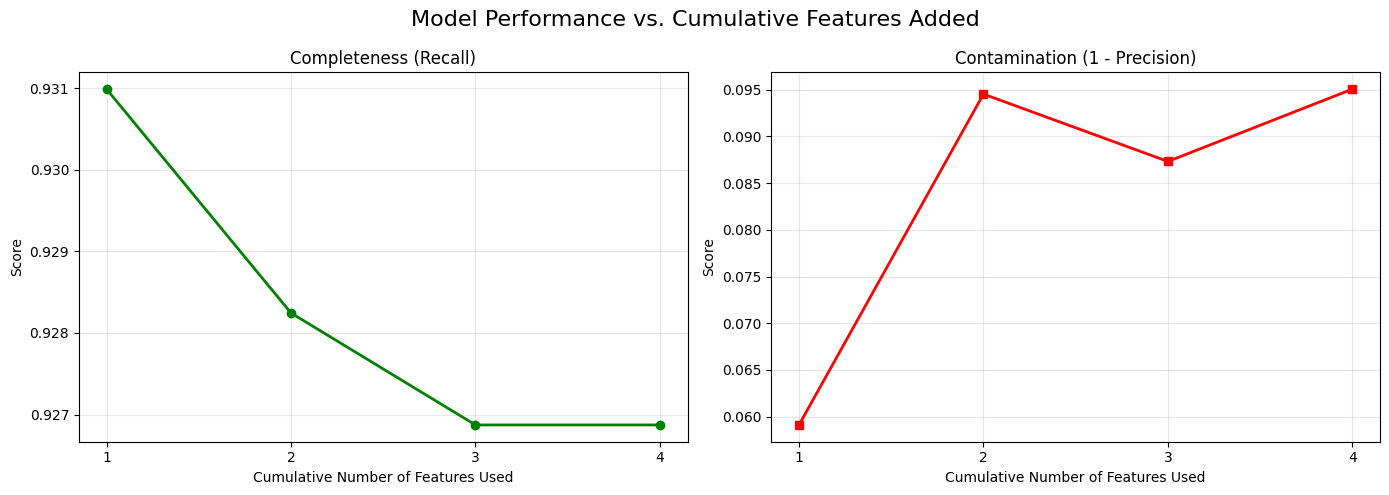

In [82]:
# # From the ROC curves, we can see that the u-g color is by far the most important feature for separating galaxies and quasars
# Compute the cumulative Completeness and Contamination for cumulatively adding features one by one in the order of their importance (u-g, g-r, r-i, i-z)

comp_list_gaus = []
cont_list_gaus = []

for i in range(X_train.shape[1]):
    # Train on first i+1 features cumulatively
    gnb.fit(X_train[:, :i+1], y_train) 
    
    # Predict hard labels
    y_pred = gnb.predict(X_test[:, :i+1])
    
    # Calculate metrics
    comp = recall_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    cont = 1.0 - prec
    
    print(f"Cumulative Features used: {color_indices[:i+1]}")
    print(f"Completeness (Recall): {comp:.3f}, Contamination (1 - Precision): {cont:.3f}")
    
    comp_list_gaus.append(comp)
    cont_list_gaus.append(cont)


# Cumulative
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x_axis = range(1, X_train.shape[1] + 1)


axes[0].plot(x_axis, comp_list_gaus, marker='o', color='green', linewidth=2)
axes[0].set_title("Completeness (Recall)")
axes[0].set_xlabel("Cumulative Number of Features Used")
axes[0].set_ylabel("Score")
axes[0].set_xticks(x_axis)
axes[0].grid(alpha=0.3)

# Contamination Subplot
axes[1].plot(x_axis, cont_list_gaus, marker='s', color='red', linewidth=2)
axes[1].set_title("Contamination (1 - Precision)")
axes[1].set_xlabel("Cumulative Number of Features Used")
axes[1].set_ylabel("Score")
axes[1].set_xticks(x_axis)
axes[1].grid(alpha=0.3)

plt.suptitle("Model Performance vs. Cumulative Features Added", fontsize=16)
plt.tight_layout()
plt.show()

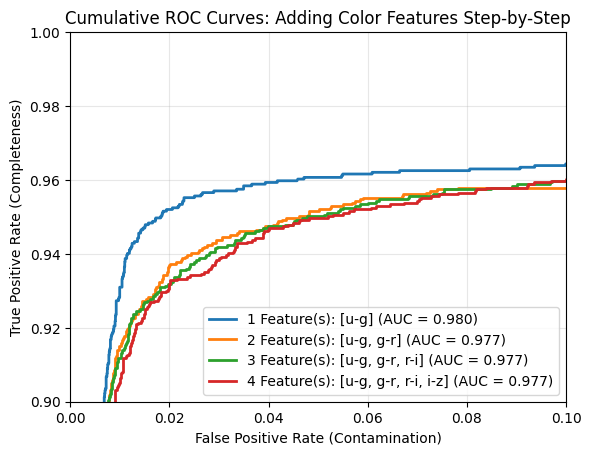

In [83]:
# Cumulative ROC curves (using all the features cumulatively)

for i in range(X_train.shape[1]):

    gnb.fit(X_train[:, :i+1], y_train)

    y_prob = gnb.predict_proba(X_test[:, :i+1])[:, 1]
    
    fpr, tpr, _ = roc_curve(y_test, y_prob) #Compute the ROC curve
    roc_auc = sklearn.metrics.auc(fpr, tpr) # Calculate AUC for this feature combination
    
    current_features = ", ".join(color_indices[:i+1])
    plt.plot(fpr, tpr, lw=2, label=f'{i+1} Feature(s): [{current_features}] (AUC = {roc_auc:.3f})')

# Plot formatting
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Contamination)')
plt.ylabel('True Positive Rate (Completeness)')
plt.title('Cumulative ROC Curves: Adding Color Features Step-by-Step')
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)
plt.xlim(0,0.1)
plt.ylim(0.9,1)
plt.show()

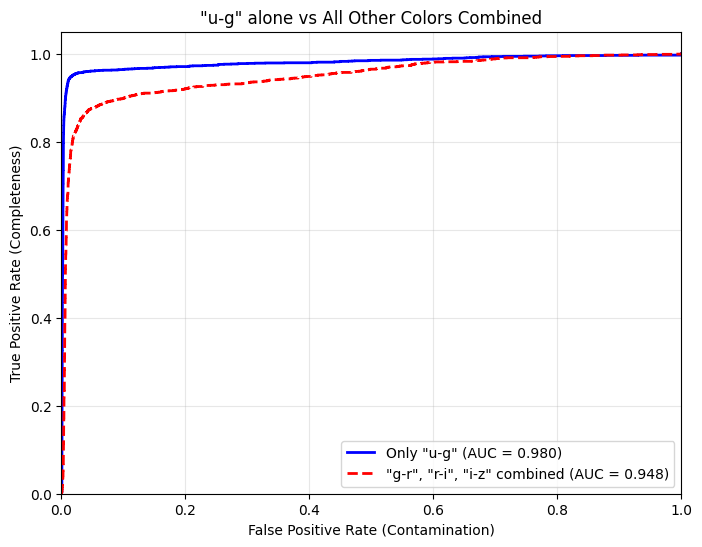

In [84]:
# Check if using features 2,3,4 (g-r, r-i, i-z) can reach the same performance as using just the u-g color

plt.figure(figsize=(8, 6))

# 'u-g' alone
gnb.fit(X_train[:, 0:1], y_train)

y_prob_ug = gnb.predict_proba(X_test[:, 0:1])[:, 1]
fpr_ug, tpr_ug, _ = roc_curve(y_test, y_prob_ug)
auc_ug = sklearn.metrics.auc(fpr_ug, tpr_ug)

plt.plot(fpr_ug, tpr_ug, lw=2, color='blue', 
         label=f'Only "u-g" (AUC = {auc_ug:.3f})')

#'g-r', 'r-i', 'i-z' combined (Indices 1, 2, 3) 
# We use 1:4 to select columns 1, 2, and 3
gnb.fit(X_train[:, 1:4], y_train)

y_prob_others = gnb.predict_proba(X_test[:, 1:4])[:, 1]
fpr_others, tpr_others, _ = roc_curve(y_test, y_prob_others)
auc_others = sklearn.metrics.auc(fpr_others, tpr_others)

plt.plot(fpr_others, tpr_others, lw=2, color='red', linestyle='--', 
         label=f'"g-r", "r-i", "i-z" combined (AUC = {auc_others:.3f})')


plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Contamination)')
plt.ylabel('True Positive Rate (Completeness)')
plt.title('"u-g" alone vs All Other Colors Combined')
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)

plt.show()

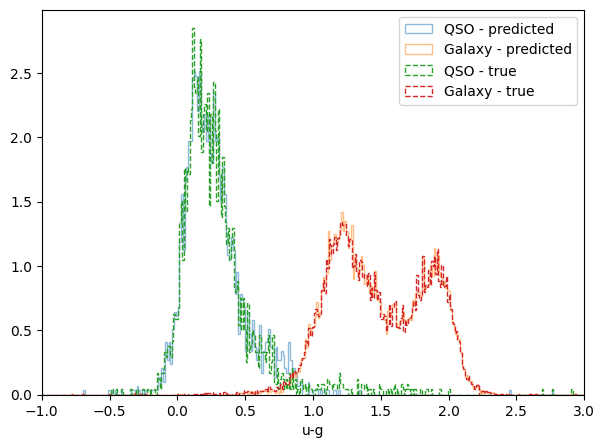

In [85]:
plt.figure(figsize=(7, 5))
plt.hist((X_test[:,0])[y_pred==1], histtype='step', bins=500, label='QSO - predicted', density=True, alpha=0.5)
plt.hist((X_test[:,0])[y_pred==0], histtype='step', bins=500, label='Galaxy - predicted', density=True, alpha=0.5)
plt.hist((X_test[:,0])[y_test==1], histtype='step', linestyle='--', bins=500, label='QSO - true', density=True)
plt.hist((X_test[:,0])[y_test==0], histtype='step', linestyle='--', bins=500, label='Galaxy - true', density=True)
plt.xlim(-1,3)
plt.legend(loc='upper right')
plt.xlabel('u-g')
plt.show()

Feature used: u-g, AUC: 0.980
Feature used: g-r, AUC: 0.942
Feature used: r-i, AUC: 0.891
Feature used: i-z, AUC: 0.840


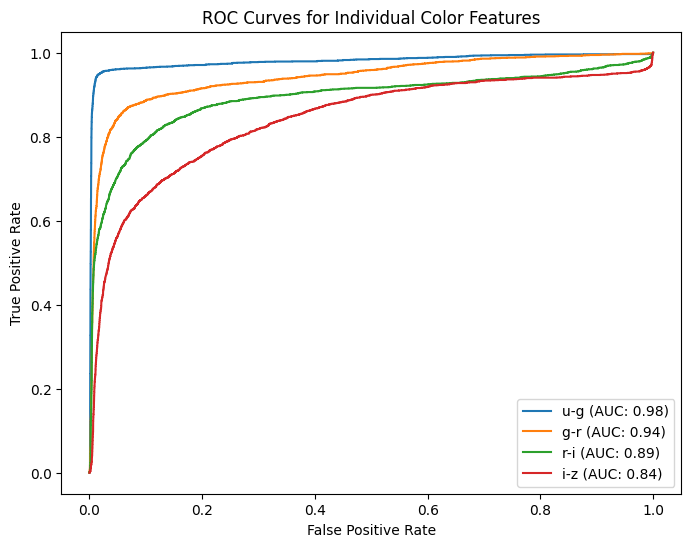

In [86]:
# Now I use the Linear Discriminant Analysis classifier we can see which is the most important feature for separating the two classes

lda = LinearDiscriminantAnalysis()
auc_scores_lda = []
plt.figure(figsize=(8, 6))

for i in range(X_train.shape[1]):
    lda.fit(X_train[:, i:i+1], y_train)
    
    # Get probabilities for ROC
    y_prob = lda.predict_proba(X_test[:, i:i+1])[:, 1]
    auc_score = roc_auc_score(y_test, y_prob)
    auc_scores_lda.append(auc_score)
    print(f"Feature used: {color_indices[i]}, AUC: {auc_score:.3f}")
    
    # Plot ROC
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{color_indices[i]} (AUC: {auc_score:.2f})")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Individual Color Features")
plt.legend(loc='lower right')
plt.show()


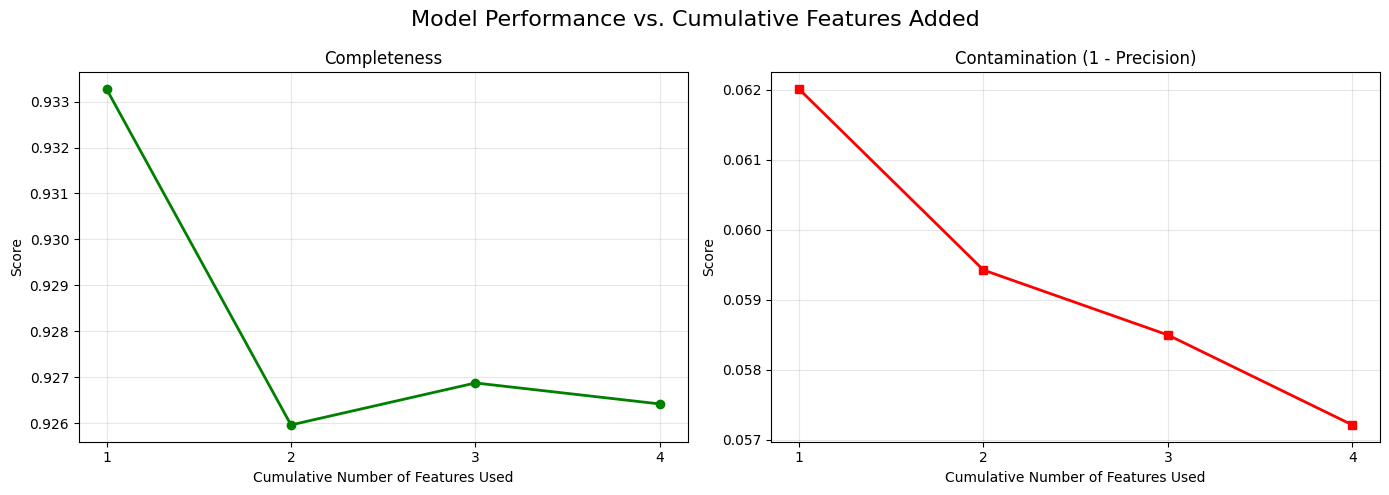

In [87]:
#Cumulative Completeness and Contamination
comp_list_lda = []
cont_list_lda = []

for i in range(X_train.shape[1]):
    lda.fit(X_train[:, :i+1], y_train)

    y_pred = lda.predict(X_test[:, :i+1])
    
    # Calculate metrics
    comp = recall_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    cont = 1.0 - prec
    
    comp_list_lda.append(comp)
    cont_list_lda.append(cont)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x_axis = range(1, X_train.shape[1] + 1)

# Completness
axes[0].plot(x_axis, comp_list_lda, marker='o', color='green', linewidth=2)
axes[0].set_title("Completeness")
axes[0].set_xlabel("Cumulative Number of Features Used")
axes[0].set_ylabel("Score")
axes[0].set_xticks(x_axis)
axes[0].grid(alpha=0.3)

# Contamination
axes[1].plot(x_axis, cont_list_lda, marker='s', color='red', linewidth=2)
axes[1].set_title("Contamination (1 - Precision)")
axes[1].set_xlabel("Cumulative Number of Features Used")
axes[1].set_ylabel("Score")
axes[1].set_xticks(x_axis)
axes[1].grid(alpha=0.3)

plt.suptitle("Model Performance vs. Cumulative Features Added", fontsize=16)
plt.tight_layout()
plt.show()

Feature used: u-g, AUC: 0.980
Feature used: g-r, AUC: 0.942
Feature used: r-i, AUC: 0.899
Feature used: i-z, AUC: 0.841


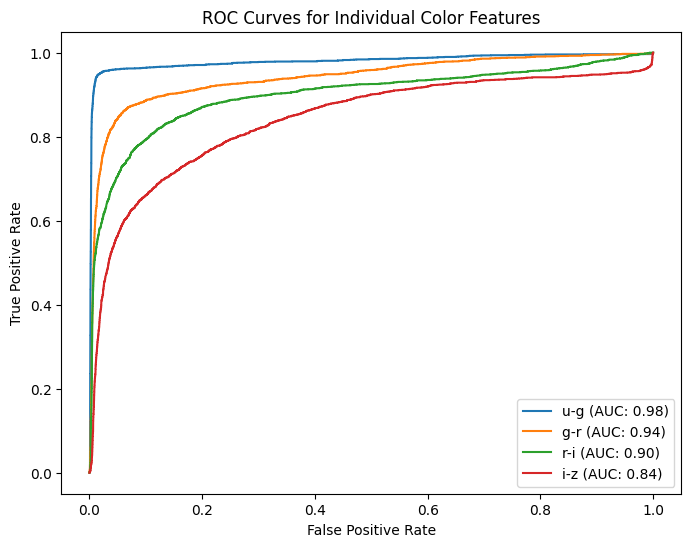

In [88]:
# using the Quadratic Discriminant Analysis (QDA) classifier we can see which is the most important feature for separating the two classes
qda = QuadraticDiscriminantAnalysis()
auc_scores_qda =[]
plt.figure(figsize=(8, 6))

for i in range(X_train.shape[1]):
    qda.fit(X_train[:, i:i+1], y_train)
    
    # Get probabilities for ROC
    y_prob = qda.predict_proba(X_test[:, i:i+1])[:, 1]
    auc_score = roc_auc_score(y_test, y_prob)
    auc_scores_qda.append(auc_score)
    print(f"Feature used: {color_indices[i]}, AUC: {auc_score:.3f}")
    
    # Plot ROC
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{color_indices[i]} (AUC: {auc_score:.2f})")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Individual Color Features")
plt.legend(loc='lower right')
plt.show()



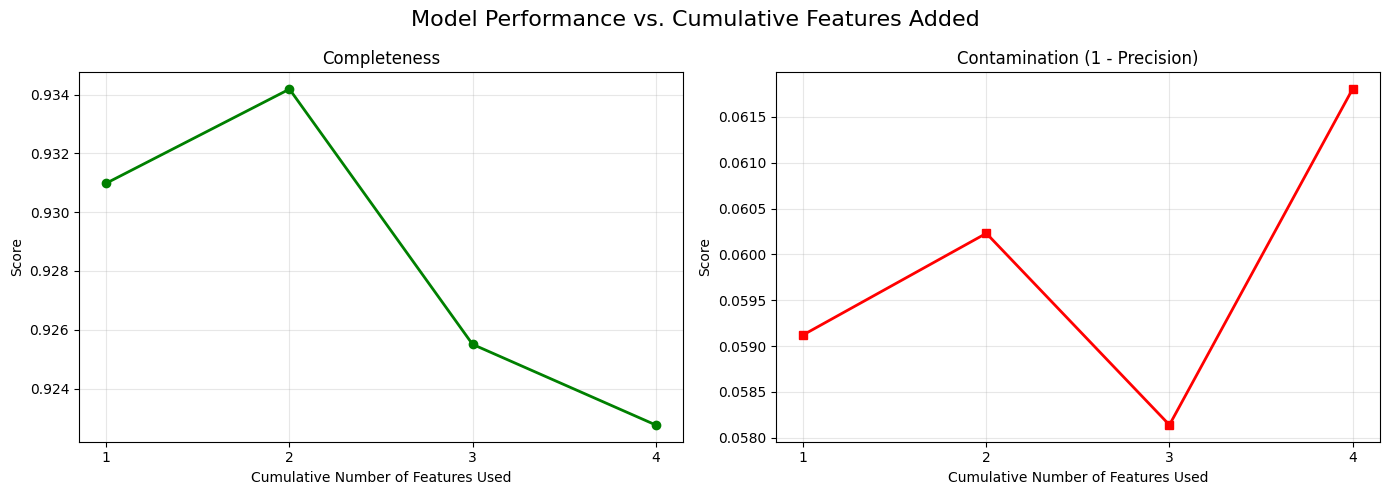

In [89]:
#Cumulative Completeness and Contamination
comp_list_qda = []
cont_list_qda = []

for i in range(X_train.shape[1]):
    
    qda.fit(X_train[:, :i+1], y_train)
    
    y_pred = qda.predict(X_test[:, :i+1])
    
    # Calculate metrics
    comp = recall_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    cont = 1.0 - prec
    
    comp_list_qda.append(comp)
    cont_list_qda.append(cont)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x_axis = range(1, X_train.shape[1] + 1)

# Completness
axes[0].plot(x_axis, comp_list_qda, marker='o', color='green', linewidth=2)
axes[0].set_title("Completeness")
axes[0].set_xlabel("Cumulative Number of Features Used")
axes[0].set_ylabel("Score")
axes[0].set_xticks(x_axis)
axes[0].grid(alpha=0.3)

# Contamination
axes[1].plot(x_axis, cont_list_qda, marker='s', color='red', linewidth=2)
axes[1].set_title("Contamination (1 - Precision)")
axes[1].set_xlabel("Cumulative Number of Features Used")
axes[1].set_ylabel("Score")
axes[1].set_xticks(x_axis)
axes[1].grid(alpha=0.3)

plt.suptitle("Model Performance vs. Cumulative Features Added", fontsize=16)
plt.tight_layout()
plt.show()

BEST MODEL PERFORMANCES
Gaussian NB
Highest AUC:           0.9801 | Using 1 features: ['u-g']
Highest Completeness:  0.9310 | Using 1 features: ['u-g']
Lowest Contamination:  0.0591 | Using 1 features: ['u-g']
LDA
Highest AUC:           0.9801 | Using 1 features: ['u-g']
Highest Completeness:  0.9333 | Using 1 features: ['u-g']
Lowest Contamination:  0.0572 | Using 4 features: ['u-g', 'g-r', 'r-i', 'i-z']
QDA
Highest AUC:           0.9801 | Using 1 features: ['u-g']
Highest Completeness:  0.9342 | Using 2 features: ['u-g', 'g-r']
Lowest Contamination:  0.0581 | Using 3 features: ['u-g', 'g-r', 'r-i']


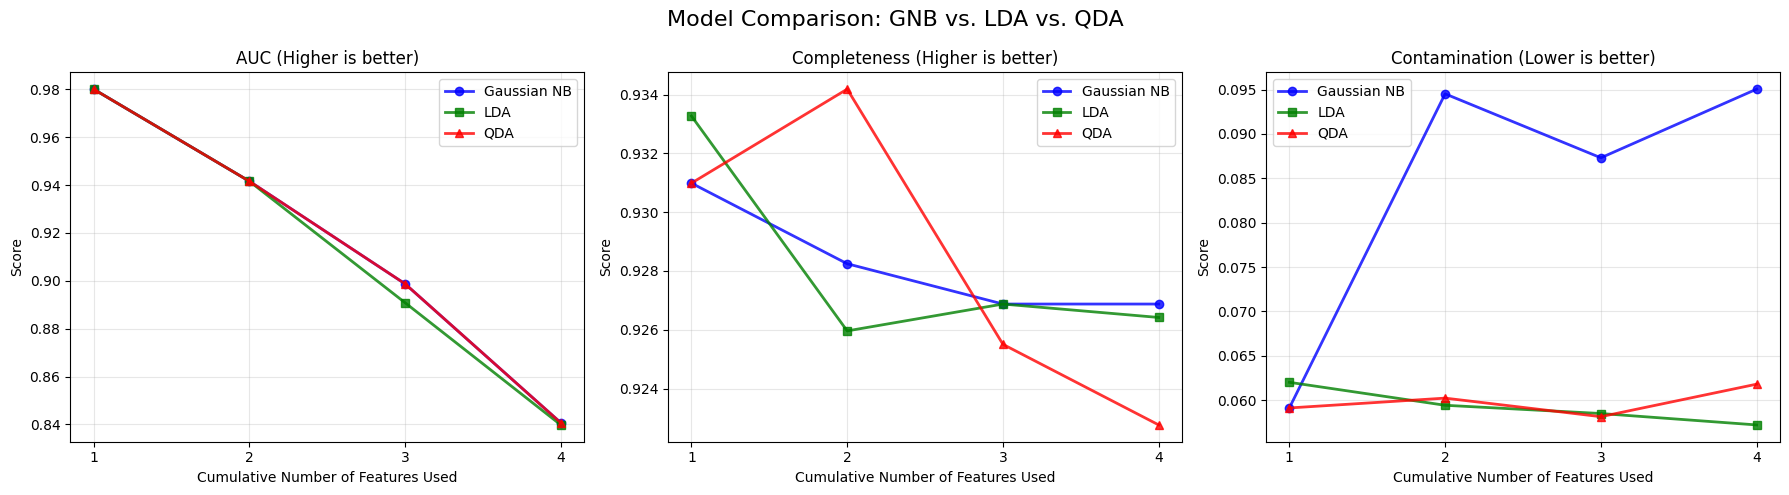

In [94]:

models_data = {
    "Gaussian NB": {"auc": auc_scores_gaus, "comp": comp_list_gaus, "cont": cont_list_gaus},
    "LDA": {"auc": auc_scores_lda, "comp": comp_list_lda, "cont": cont_list_lda},
    "QDA": {"auc": auc_scores_qda, "comp": comp_list_qda, "cont": cont_list_qda}
}


print("BEST MODEL PERFORMANCES")

for name, metrics in models_data.items():

    # Find the list index where the max/min occurs
    best_auc_idx = np.argmax(metrics['auc'])
    best_comp_idx = np.argmax(metrics['comp'])
    best_cont_idx = np.argmin(metrics['cont'])
    
    # Extract the actual best score values
    auc_val = metrics['auc'][best_auc_idx]
    comp_val = metrics['comp'][best_comp_idx]
    cont_val = metrics['cont'][best_cont_idx]
    
    auc_feats = color_indices[:best_auc_idx + 1]
    comp_feats = color_indices[:best_comp_idx + 1]
    cont_feats = color_indices[:best_cont_idx + 1]

    print(f"{name}")
    print(f"Highest AUC:           {auc_val:.4f} | Using {len(auc_feats)} features: {auc_feats}")
    print(f"Highest Completeness:  {comp_val:.4f} | Using {len(comp_feats)} features: {comp_feats}")
    print(f"Lowest Contamination:  {cont_val:.4f} | Using {len(cont_feats)} features: {cont_feats}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
x_axis = range(1, len(color_indices) + 1)

colors = {"Gaussian NB": "blue", "LDA": "green", "QDA": "red"}
markers = {"Gaussian NB": "o", "LDA": "s", "QDA": "^"}

for name, metrics in models_data.items():
    # Plot AUC
    axes[0].plot(x_axis, metrics['auc'], label=name, 
                 color=colors[name], marker=markers[name], lw=2, alpha=0.8)
    # Plot Completeness
    axes[1].plot(x_axis, metrics['comp'], label=name, 
                 color=colors[name], marker=markers[name], lw=2, alpha=0.8)
    # Plot Contamination
    axes[2].plot(x_axis, metrics['cont'], label=name, 
                 color=colors[name], marker=markers[name], lw=2, alpha=0.8)

# Format Subplots
titles_and_axes = [
    ("AUC (Higher is better)", axes[0]), 
    ("Completeness (Higher is better)", axes[1]), 
    ("Contamination (Lower is better)", axes[2])
]

for title, ax in titles_and_axes:
    ax.set_title(title)
    ax.set_xlabel("Cumulative Number of Features Used")
    ax.set_ylabel("Score")
    ax.set_xticks(x_axis)
    ax.grid(alpha=0.3)
    ax.legend(loc="best")

plt.suptitle("Model Comparison: GNB vs. LDA vs. QDA", fontsize=16)
plt.tight_layout()
plt.show()

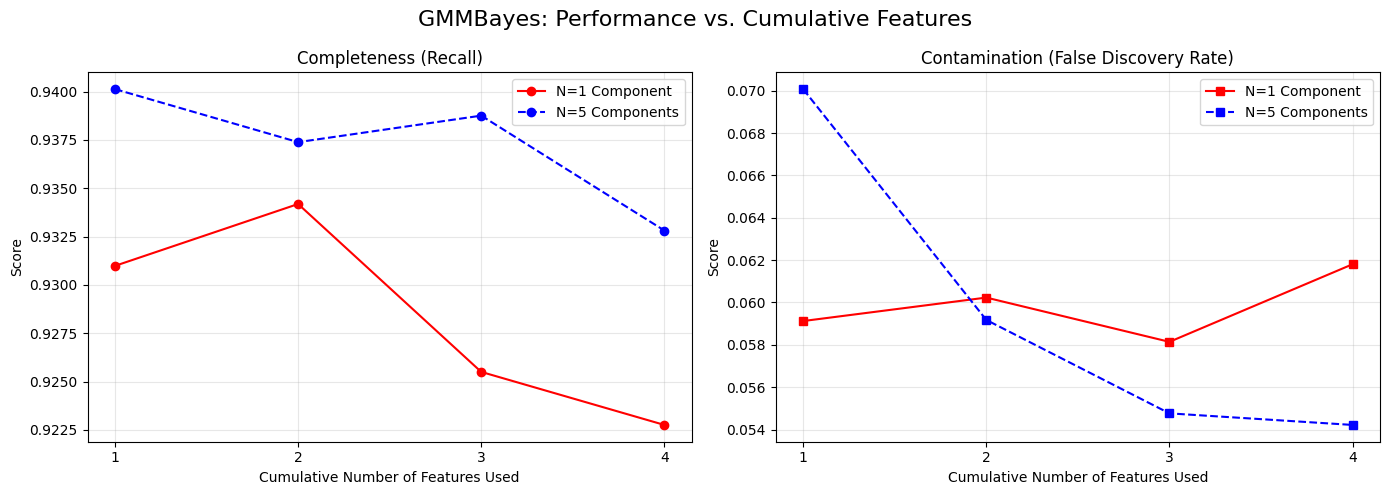

GMM with 1 component 
Completeness = [0.931 0.934 0.926 0.923] 
Contamination = [0.059 0.06  0.058 0.062]

GMM with 5 components 
Completeness = [0.94  0.937 0.939 0.933] 
Contamination = [0.07  0.059 0.055 0.054]


In [96]:
# Now we try to use GMM Bayes classifier to see if we can improve the classification performance

clusters = [1, 5] # single Gaussian vs. more complex distribution with 5 components

# Create a list of the number of features [1, 2, 3, 4]
num_features = range(1, X_train.shape[1] + 1)

comp_dict = {1: [], 5: []}
cont_dict = {1: [], 5: []}

for c in clusters:
    for x in num_features:

        gmm = GMMBayes(c, covariance_type='full') 
        gmm.fit(X_train[:, :x], y_train)

        y_pred = gmm.predict(X_test[:, :x])
        
        # Calculate metrics
        comp = recall_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, zero_division=0)
        cont = 1.0 - prec
        
        # Store the results in the appropriate dictionary list
        comp_dict[c].append(comp)
        cont_dict[c].append(cont)

# Plot the results as subplots for both N=1 and N=5 components
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Completeness (Higher is better)
axes[0].plot(num_features, comp_dict[1], marker='o', color='red', label='N=1 Component')
axes[0].plot(num_features, comp_dict[5], marker='o', linestyle='--', color='blue', label='N=5 Components')
axes[0].set_title('Completeness (Recall)')
axes[0].set_xlabel('Cumulative Number of Features Used')
axes[0].set_ylabel('Score')
axes[0].set_xticks(num_features)
axes[0].grid(alpha=0.3)
axes[0].legend()

# Contamination (Lower is better)
axes[1].plot(num_features, cont_dict[1], marker='s', color='red', label='N=1 Component')
axes[1].plot(num_features, cont_dict[5], marker='s', linestyle='--', color='blue', label='N=5 Components')
axes[1].set_title('Contamination (False Discovery Rate)')
axes[1].set_xlabel('Cumulative Number of Features Used')
axes[1].set_ylabel('Score')
axes[1].set_xticks(num_features)
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.suptitle("GMMBayes: Performance vs. Cumulative Features", fontsize=16)
plt.tight_layout()
plt.show()

# Print out the exact numbers for analysis
print(f"GMM with 1 component \nCompleteness = {np.round(comp_dict[1], 3)} \nContamination = {np.round(cont_dict[1], 3)}\n")
print(f"GMM with 5 components \nCompleteness = {np.round(comp_dict[5], 3)} \nContamination = {np.round(cont_dict[5], 3)}")

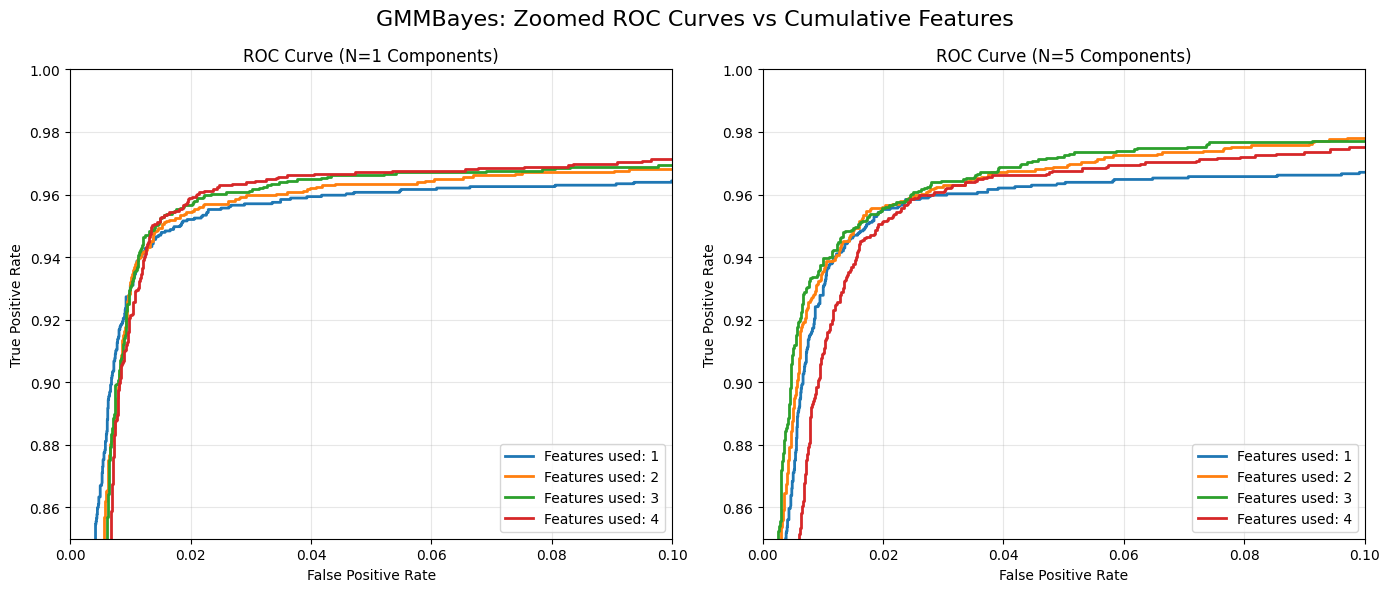

In [91]:
# Cumulative ROC curves for GMMBayes with N=1 and N=5 components
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

clusters = [1, 5]
num_features_list = range(1, X_train.shape[1] + 1)

for idx, c in enumerate(clusters):
    ax = axes[idx] 
    
    for x in num_features_list:
        gmm = GMMBayes(c, covariance_type='full')
        gmm.fit(X_train[:, :x], y_train)
        
        y_prob = gmm.predict_proba(X_test[:, :x])[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        
        ax.plot(fpr, tpr, lw=2, label=f'Features used: {x}')
    
    # Plot
    ax.set_xlim([0.0, 0.1])
    ax.set_ylim([0.85, 1.0])
    
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC Curve (N={c} Components)')
    ax.legend(loc='lower right')
    ax.grid(alpha=0.3)

plt.suptitle("GMMBayes: Zoomed ROC Curves vs Cumulative Features", fontsize=16)
plt.tight_layout()
plt.show()

In [97]:
# Use GridserchCV to find optimal number of components

param_grid = {'n_components': np.arange(1, 11)}

gmm_cv = GMMBayes(covariance_type='full')

grid_search = GridSearchCV(gmm_cv, param_grid, cv=5, scoring='roc_auc')
grid_search.fit(X_train, y_train)

best_n = grid_search.best_params_['n_components']
best_score = grid_search.best_score_

print(f"Optimal Number of Components: {best_n}")
print(f"Best Mean CV AUC Score:       {best_score:.4f}")

# Plot 
mean_scores = grid_search.cv_results_['mean_test_score']
std_scores = grid_search.cv_results_['std_test_score']

plt.figure(figsize=(8, 5))

# Plot the mean scores with error bars representing the standard deviation across the 5 folds
plt.errorbar(param_grid['n_components'], mean_scores, yerr=std_scores, 
             fmt='-o', color='purple', ecolor='lightgray', capsize=4, elinewidth=2, markersize=8)

# Highlight the best score
plt.scatter(best_n, best_score, color='gold', edgecolor='black', s=150, zorder=5, label=f'Best: N={best_n}')

plt.title('Cross-Validation Performance of GMMBayes', fontsize=14)
plt.xlabel('Number of Gaussian Components (N)')
plt.ylabel('Mean CV AUC Score')
plt.xticks(param_grid['n_components'])
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

RuntimeError: Cannot clone object GMMBayes(n_components=8), as the constructor either does not set or modifies parameter n_components

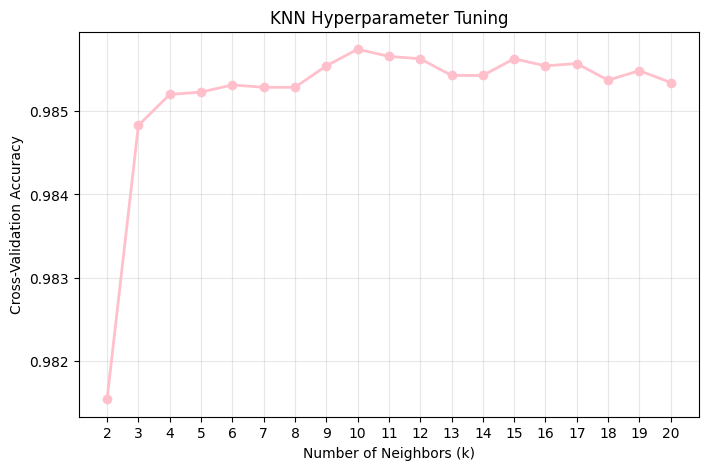

Best number of neighbors: k=10 (Validation Accuracy: 0.9857)

--- Metrics for KNN (k=10) ---
Completeness = [0.92  0.921 0.938 0.936]
Contamination = [0.051 0.048 0.042 0.038]



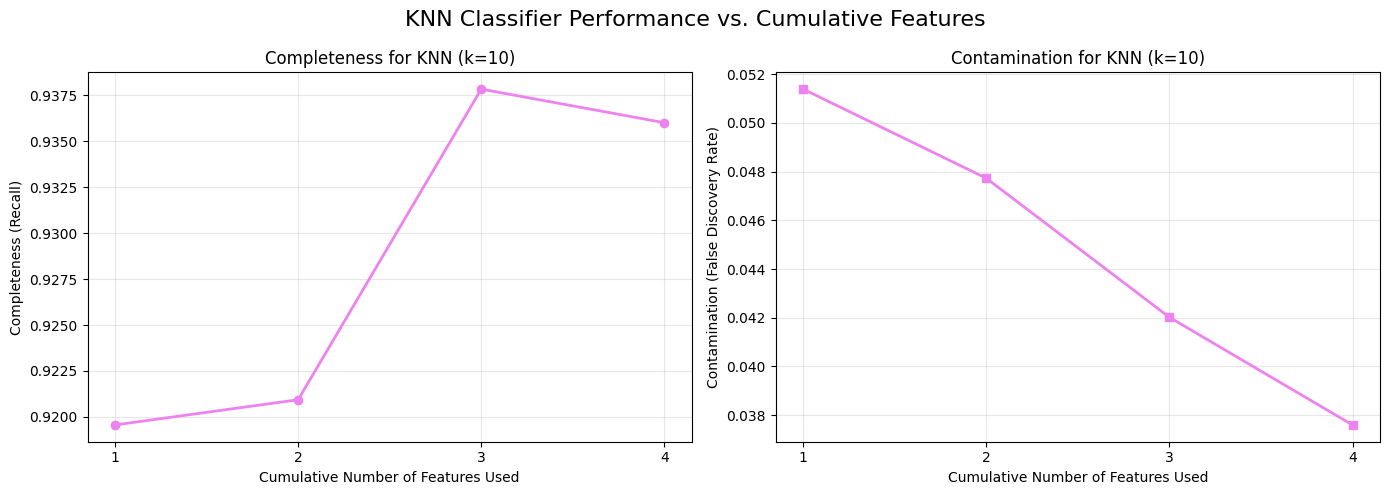

In [92]:
# Now we can use the K-Nearest Neighbors (KNN) classifier with cross-validation to see how it performs compared to the previous models. We will use the same cumulative feature approach to see how the performance changes as we add more features.

param_grid = {'n_neighbors': range(2, 21)} # We will test k values from 2 to 20
knn = KNeighborsClassifier()

# Grid search with 5-fold cross-validation
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy') # We are optimizing for accuracy here, but we could also optimize for AUC or another metric if desired
grid_search.fit(X_train, y_train) 

# Extract results
val_scores = grid_search.cv_results_['mean_test_score']
k_values = range(2, 21)

# Plot Grid Search Results
plt.figure(figsize=(8, 5))
plt.plot(k_values, val_scores, marker='o', color='pink', lw=2)
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Cross-Validation Accuracy')
plt.title('KNN Hyperparameter Tuning')
plt.xticks(k_values)
plt.grid(alpha=0.3)
plt.show()

# Extract the best 'k' and its corresponding score
best_k = grid_search.best_params_['n_neighbors']
best_score = grid_search.best_score_
print(f'Best number of neighbors: k={best_k} (Validation Accuracy: {best_score:.4f})')


# Initialize the best model
knn_best = KNeighborsClassifier(n_neighbors=best_k)

num_features_list = range(1, X_train.shape[1] + 1)
comp_list = []
cont_list = []

for x in num_features_list:
    
    knn_best.fit(X_train[:, :x], y_train)
   
    y_pred = knn_best.predict(X_test[:, :x])
    
    # Calculate Completeness and Contamination (1 - Precision)
    comp = recall_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    cont = 1.0 - prec
    
    comp_list.append(comp)
    cont_list.append(cont)

print(f'\n--- Metrics for KNN (k={best_k}) ---')
print(f'Completeness = {np.round(comp_list, 3)}')
print(f'Contamination = {np.round(cont_list, 3)}\n')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Completeness
axes[0].plot(num_features_list, comp_list, marker='o', color='violet', lw=2)
axes[0].set_xlabel('Cumulative Number of Features Used')
axes[0].set_ylabel('Completeness (Recall)')
axes[0].set_title(f'Completeness for KNN (k={best_k})')
axes[0].set_xticks(num_features_list)
axes[0].grid(alpha=0.3)

# Contamination
axes[1].plot(num_features_list, cont_list, marker='s', color='violet', lw=2)
axes[1].set_xlabel('Cumulative Number of Features Used')
axes[1].set_ylabel('Contamination (False Discovery Rate)')
axes[1].set_title(f'Contamination for KNN (k={best_k})')
axes[1].set_xticks(num_features_list)
axes[1].grid(alpha=0.3)

plt.suptitle(f"KNN Classifier Performance vs. Cumulative Features", fontsize=16)
plt.tight_layout()
plt.show()